# Retail Demand Forecasting using Statistical, Machine Learning, and Deep Learning Models

---

## 1. Business Understanding

### Objective

Demand forecasting is an important task in the retail industry as it helps businesses estimate future product demand using historical sales data. Accurate forecasts support inventory planning, reduce stock shortages, minimize excess inventory, and improve overall business decision-making.

In this project, historical daily sales data is analyzed to understand sales patterns and build forecasting models. Different forecasting approaches, including statistical, machine learning, and deep learning models, will be compared to identify the most suitable method for predicting future retail sales.

# Import Libraries

**Objective:** Import the required libraries for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings to keep the notebook clean
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


---
# Load Dataset

**Objective:** Load the training, testing, and sample submission datasets into the notebook.

In [2]:
# Load the datasets from the data folder
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample_submission = pd.read_csv('data/sample_submission.csv')

---
# Dataset Understanding

**Objective:** Understand the structure and quality of the datasets before analysis.

In [3]:
# 1. Display the shape of each dataset
print("Train dataset shape:", train.shape)
print("Test dataset shape:", test.shape)

# 2. Display the column names
print("\nTrain dataset columns:", train.columns.tolist())
print("Test dataset columns:", test.columns.tolist())

# 3. Display data types using .info()
print("\nTrain dataset info:")
train.info()
print("\nTest dataset info:")
test.info()

# 4. Display summary statistics using .describe()
print("\nTrain dataset summary statistics:")
print(train.describe())
print("\nTest dataset summary statistics:")
print(test.describe())

# 5. Check missing values
print("\nMissing values in Train dataset:")
print(train.isnull().sum())
print("\nMissing values in Test dataset:")
print(test.isnull().sum())

# 6. Check duplicate rows
print("\nDuplicate rows in Train dataset:", train.duplicated().sum())
print("\nDuplicate rows in Test dataset:", test.duplicated().sum())

Train dataset shape: (913000, 4)
Test dataset shape: (45000, 4)

Train dataset columns: ['date', 'store', 'item', 'sales']
Test dataset columns: ['id', 'date', 'store', 'item']

Train dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB

Test dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      45000 non-null  int64
 1   date    45000 non-null  str  
 2   store   45000 non-null  int64
 3   item    45000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.4 MB

Train dataset summary statistics:


               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000
50%         5.500000      25.500000      47.000000
75%         8.000000      38.000000      70.000000
max        10.000000      50.000000     231.000000

Test dataset summary statistics:
                 id         store         item
count  45000.000000  45000.000000  45000.00000
mean   22499.500000      5.500000     25.50000
std    12990.525394      2.872313     14.43103
min        0.000000      1.000000      1.00000
25%    11249.750000      3.000000     13.00000
50%    22499.500000      5.500000     25.50000
75%    33749.250000      8.000000     38.00000
max    44999.000000     10.000000     50.00000

Missing values in Train dataset:
date     0
store    0
item     0
sales    0
dtype:

### Key Observations

- The training dataset contains **913,000** records, while the test dataset contains **45,000** records.
- The training dataset has **4 columns** (`date`, `store`, `item`, `sales`), whereas the test dataset contains `id` instead of `sales`.
- No missing values or duplicate records were found in either dataset.
- The `date` column is currently stored as a string and will be converted to datetime during preprocessing.
---

# Data Preprocessing

**Objective:** Prepare the dataset for analysis by converting data types and validating the time series structure.

In [4]:
# 1. Convert the 'date' column in both train and test datasets to datetime format
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

# 2. Display minimum and maximum dates for both datasets
print("Train date range:", train['date'].min(), "to", train['date'].max())
print("Test date range:", test['date'].min(), "to", test['date'].max())

# 3. Display number of unique stores and items
print("Number of unique stores:", train['store'].nunique())
print("Number of unique items:", train['item'].nunique())

# 4. Display the total number of unique store-item combinations in the train dataset
unique_combinations = train[['store', 'item']].drop_duplicates().shape[0]
print("Total number of unique store-item combinations:", unique_combinations)


Train date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Test date range: 2018-01-01 00:00:00 to 2018-03-31 00:00:00
Number of unique stores: 10
Number of unique items: 50
Total number of unique store-item combinations: 500


### Key Observations

- The training dataset contains daily sales records from **01-Jan-2013** to **31-Dec-2017**.
- The test dataset covers the next **3 months (01-Jan-2018 to 31-Mar-2018)** for future sales prediction.
- The data consists of **10 stores** and **50 unique items**.
- There are **500 unique store-item combinations**, meaning sales need to be forecasted for 500 individual time series.
---

# Exploratory Data Analysis (EDA)

**Objective:** Analyze historical sales data to identify trends, seasonality, and overall sales patterns.

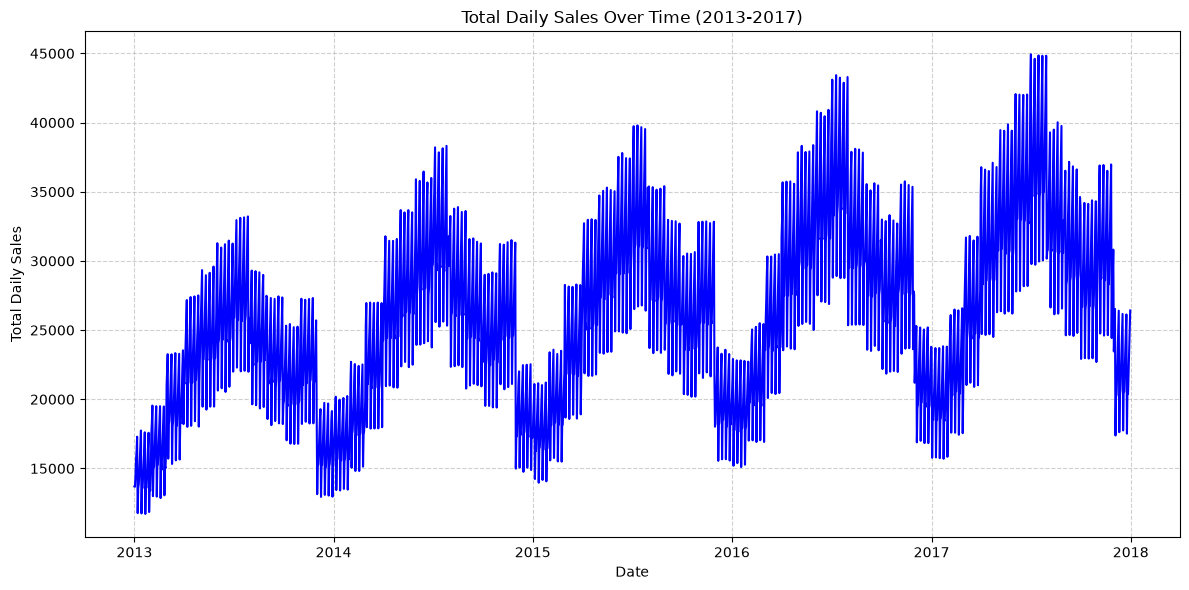

In [5]:
# Calculate total daily sales by grouping by date
daily_sales = train.groupby('date')['sales'].sum()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.values, color='blue', linewidth=1.5)

# Add chart elements
plt.title('Total Daily Sales Over Time (2013-2017)')
plt.xlabel('Date')
plt.ylabel('Total Daily Sales')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

### Key Observations

- Overall sales show an increasing trend from 2013 to 2017.
- A repeating seasonal pattern is visible every year.
- Sales fluctuate regularly, indicating weekly or monthly seasonality.
- Peak sales gradually increase over time, suggesting business growth.
---

## Sales Distribution

**Objective:** Analyze the distribution of daily sales values to understand their spread and identify any skewness or unusual patterns.

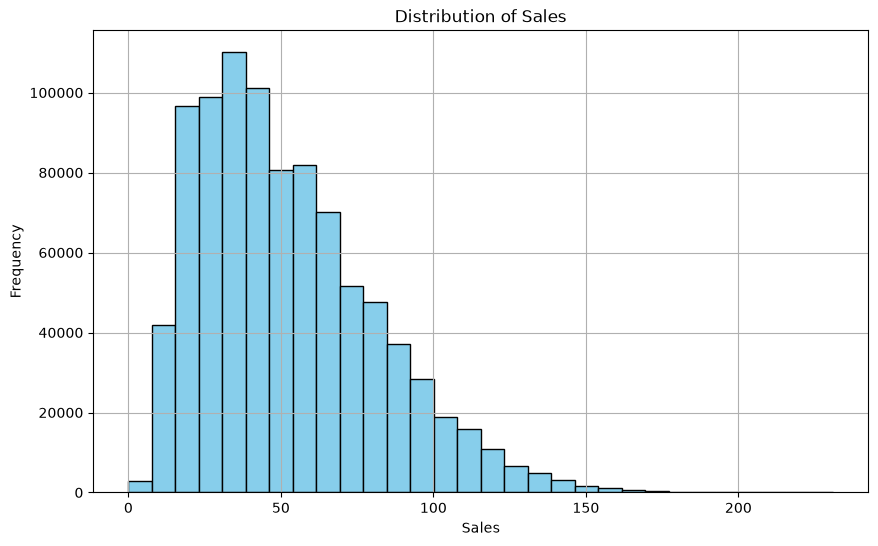

In [6]:
# Create a histogram of the sales column
plt.figure(figsize=(10, 6))
plt.hist(train['sales'], bins=30, color='skyblue', edgecolor='black')

# Add labels, title, and grid
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True)

# Show the plot
plt.show()

### Key Observations

- Most sales values lie between **20 and 70 units**.
- The distribution is **positively (right) skewed**, with fewer high sales values.
- Very high sales values are rare and may represent peak demand periods.
- The target variable is not normally distributed, which should be considered during model selection.
---

## Monthly Sales Trend

**Objective:** Analyze the average monthly sales to identify recurring seasonal patterns.

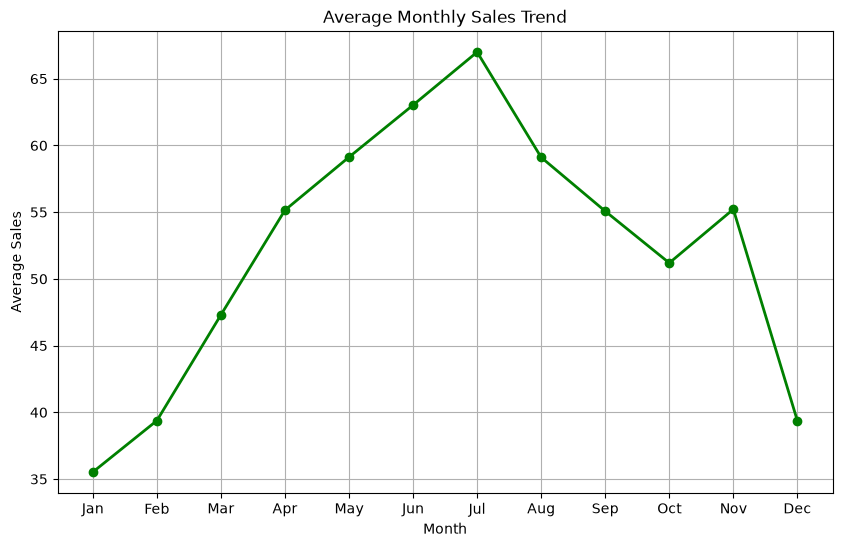

In [7]:
# 1. Create a new column named 'month' from the 'date' column
train['month'] = train['date'].dt.month

# 2. Calculate the average monthly sales
monthly_sales = train.groupby('month')['sales'].mean()

# 3. Plot the average monthly sales using a line chart
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='green', linewidth=2)

# 4. Add chart elements (title, labels, custom x-axis ticks, grid)
plt.title('Average Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Average Sales')

# Set month names (Jan to Dec) on the x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(monthly_sales.index, month_names)

plt.grid(True)

# Show the plot
plt.show()

### Key Observations

- Average sales increase steadily from **January to July**.
- **July** records the highest average sales, indicating peak seasonal demand.
- Sales decline gradually after July and reach the lowest levels in **December and January**.
- The monthly trend clearly indicates the presence of seasonality in the dataset.
---

## Yearly Sales Trend

**Objective:** Analyze the average yearly sales to understand the long-term sales trend.

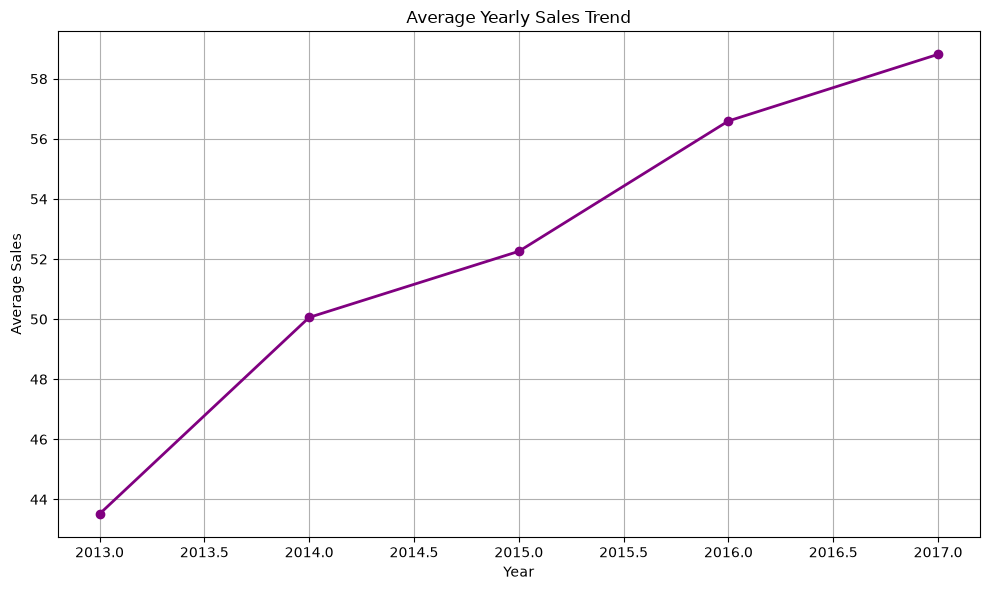

In [8]:
# 1. Create a new column named 'year' from the 'date' column
train['year'] = train['date'].dt.year

# 2. Calculate the average yearly sales
yearly_sales = train.groupby('year')['sales'].mean()

# 3. Plot the average yearly sales using a line chart
plt.figure(figsize=(10, 6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='purple', linewidth=2)

# 4. Add chart elements
plt.title('Average Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.grid(True)

# 5. Use tight layout
plt.tight_layout()

# Show the plot
plt.show()

### Key Observations

- Average yearly sales show a consistent upward trend from **2013 to 2017**.
- Sales increased every year, indicating steady business growth.
- The highest average sales were recorded in **2017**.
- The positive trend suggests increasing customer demand over time.
---

## Sales by Store

**Objective:** Compare the average sales across different stores to identify variations in store performance.

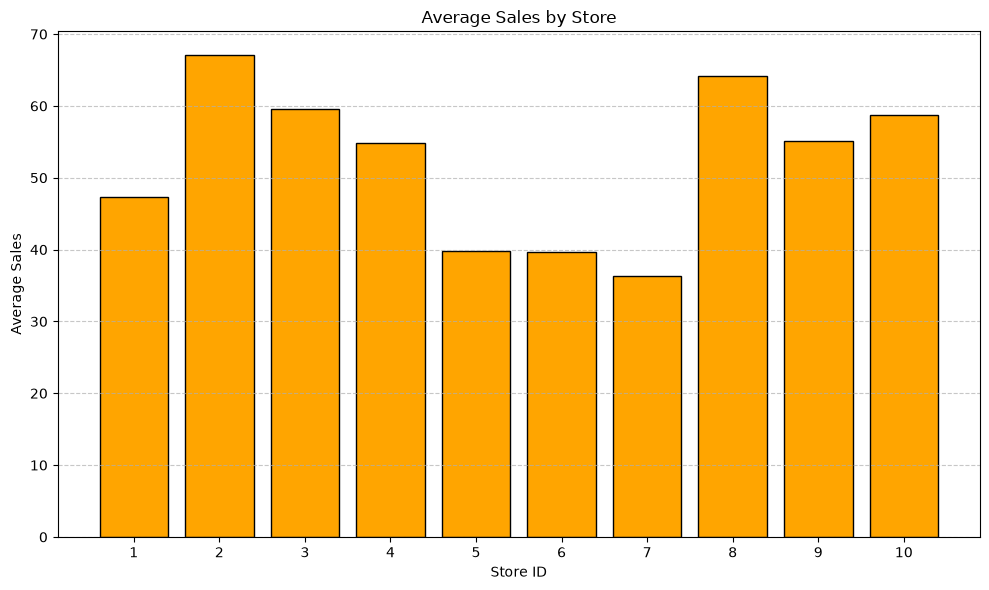

In [9]:
# 1. Calculate the average sales for each store
store_sales = train.groupby('store')['sales'].mean()

# 2. Plot the average sales using a bar chart
plt.figure(figsize=(10, 6))
plt.bar(store_sales.index, store_sales.values, color='orange', edgecolor='black')

# 3. Add chart elements
plt.title('Average Sales by Store')
plt.xlabel('Store ID')
plt.ylabel('Average Sales')
plt.xticks(store_sales.index)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# 4. Use tight layout
plt.tight_layout()

# Show the plot
plt.show()

### Key Observations

- Store performance varies across all 10 stores.
- **Store 2** has the highest average sales, followed by **Store 8**.
- **Store 7** records the lowest average sales.
- The variation suggests that customer demand differs across store locations.
---

## Sales by Item

**Objective:** Compare the average sales of different items to identify the best and least selling products.

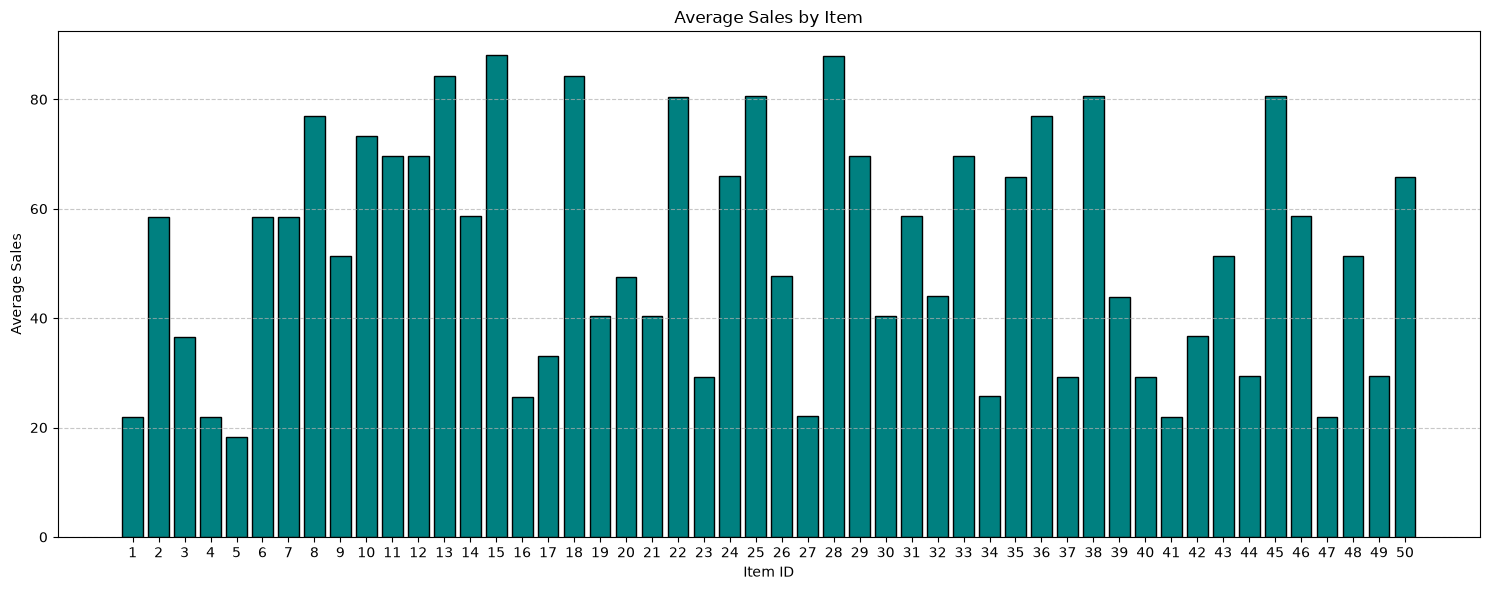

In [10]:
# 1. Calculate the average sales for each item
item_sales = train.groupby('item')['sales'].mean()

# 2. Plot the average sales using a bar chart
plt.figure(figsize=(15, 6))
plt.bar(item_sales.index, item_sales.values, color='teal', edgecolor='black')

# 3. Add chart elements
plt.title('Average Sales by Item')
plt.xlabel('Item ID')
plt.ylabel('Average Sales')
plt.xticks(item_sales.index)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# 4. Use tight layout
plt.tight_layout()

# Show the plot
plt.show()

### Key Observations

- Average sales vary significantly across different items.
- Some items consistently achieve much higher average sales than others.
- A few items have relatively low average demand.
- Item-level differences indicate that product popularity is an important factor in demand forecasting.
---

# Time Series Analysis

**Objective:** Analyze the trend, seasonality, and stationarity of the sales data before building forecasting models.

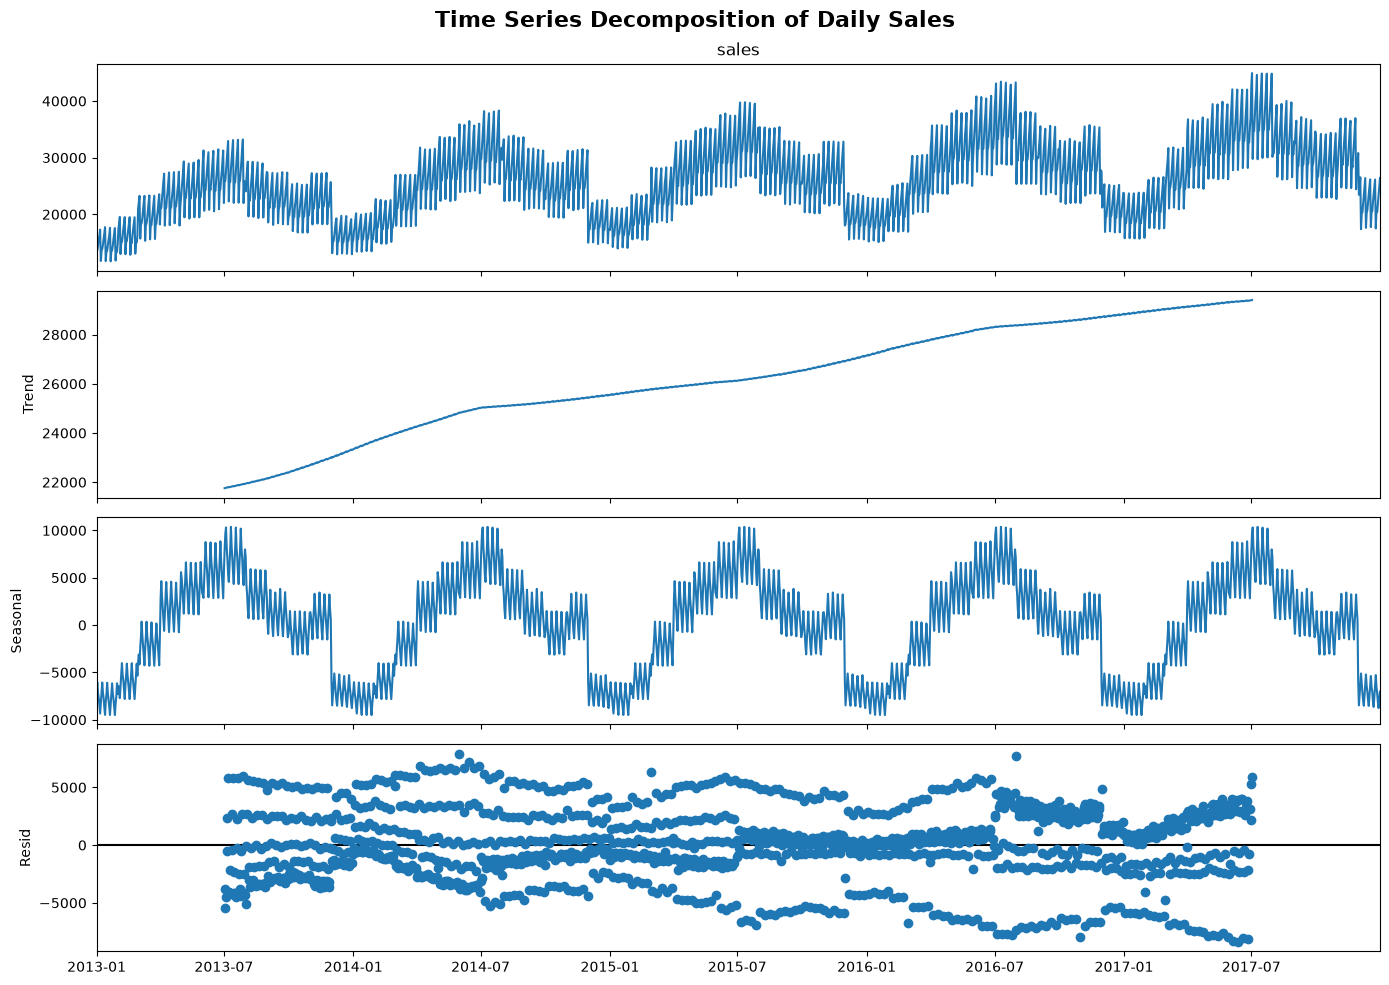

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Aggregate daily sales from the train dataset
daily_sales = train.groupby('date')['sales'].sum()
daily_sales.index.freq = 'D'

# 2. Perform additive seasonal decomposition (period = 365 for daily data with annual seasonality)
decomposition = seasonal_decompose(daily_sales, model='additive', period=365)

# 3. Plot the decomposition components (Observed, Trend, Seasonal, Residual)
fig = decomposition.plot()

# Increase figure size
fig.set_size_inches(14, 10)

# Add a main title
fig.suptitle("Time Series Decomposition of Daily Sales", fontsize=16, fontweight="bold")

# Improve spacing
plt.tight_layout()

plt.show()

### Key Observations

- The trend component shows a steady increase in sales over the five-year period.
- A strong seasonal pattern is observed, indicating recurring yearly demand.
- The residual component fluctuates around zero, representing random variations not explained by trend or seasonality.
- The presence of both trend and seasonality suggests that time series forecasting models such as SARIMA are suitable for this dataset.
---

## Stationarity Test (ADF Test)

**Objective:** Determine whether the sales time series is stationary before applying forecasting models such as SARIMA.

In [12]:
from statsmodels.tsa.stattools import adfuller

# 1. Aggregate daily sales from the train dataset
daily_sales = train.groupby('date')['sales'].sum()

# 2. Perform the Augmented Dickey-Fuller (ADF) test
result = adfuller(daily_sales)

# 3. Display ADF Statistic, p-value, and Critical Values
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

# 4. Check for stationarity based on a 0.05 significance level
if result[1] <= 0.05:
    print("\nConclusion: The time series is stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The time series is non-stationary (p-value > 0.05).")

ADF Statistic : -3.0602
p-value       : 0.0296
Critical Values:
   1%: -3.4339800605797155
   5%: -2.8631434696839992
   10%: -2.5676236347535166

Conclusion: The time series is stationary (p-value <= 0.05).


### Key Observations

- The ADF test returned a **p-value of 0.0296**, which is less than 0.05.
- The null hypothesis of non-stationarity is rejected.
- The daily sales series can be considered stationary.
- This indicates that the dataset is suitable for statistical forecasting models such as SARIMA.
---

## ACF and PACF Analysis

**Objective:** Analyze autocorrelation patterns to help determine suitable parameters for the SARIMA model.

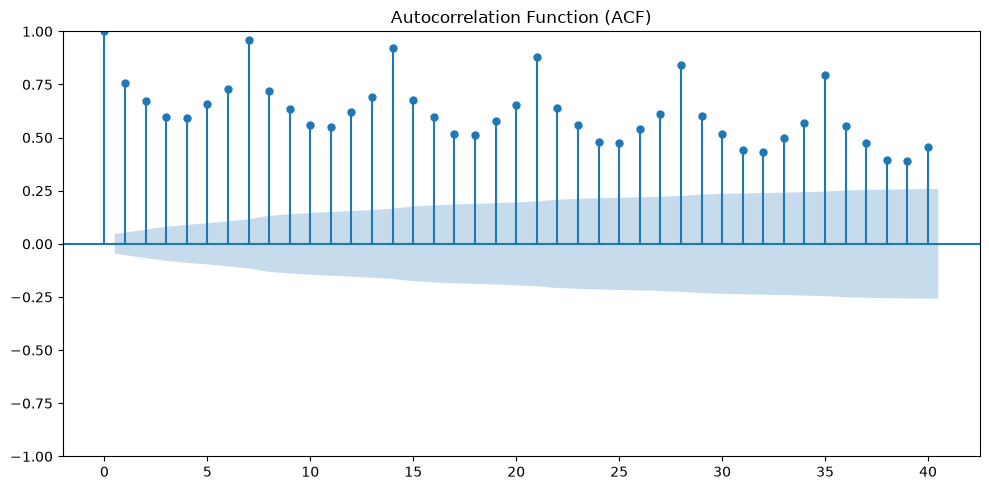

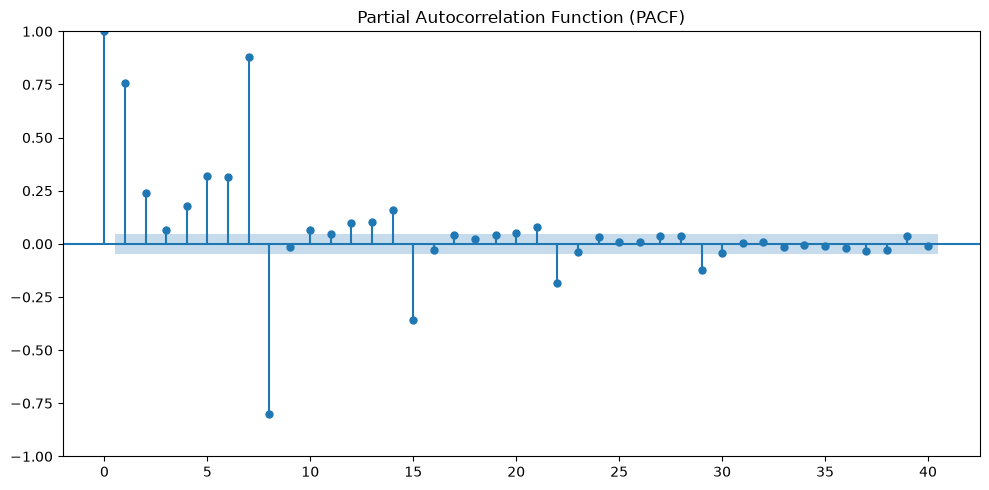

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Aggregate daily sales from the train dataset
daily_sales = train.groupby('date')['sales'].sum()

# 2. Plot Autocorrelation Function (ACF) with 40 lags
plt.figure(figsize=(10, 5))
plot_acf(daily_sales, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')
plt.tight_layout()
plt.show()

# 3. Plot Partial Autocorrelation Function (PACF) with 40 lags
plt.figure(figsize=(10, 5))
plot_pacf(daily_sales, lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()


### Key Observations

- The ACF plot shows strong positive autocorrelation across multiple lags, indicating that current sales depend on previous observations.
- The PACF plot shows significant spikes at the initial lags, suggesting that autoregressive terms may be useful.
- The presence of significant autocorrelation confirms that historical sales contain valuable information for forecasting.
- These plots provide guidance for selecting suitable SARIMA parameters.
---

# Feature Engineering

**Objective:** Create meaningful features from the date column to improve forecasting performance.

In [14]:
# Create date-based features for both train and test datasets
for df in [train, test]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.dayofweek
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Define the list of newly created columns to display
feature_cols = ['year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend']

# Display the first five rows of the new features for both datasets
print("Train dataset - Date Features:")
print(train[feature_cols].head())

print("\nTest dataset - Date Features:")
print(test[feature_cols].head())

Train dataset - Date Features:
   year  month  day  day_of_week  week_of_year  quarter  is_weekend
0  2013      1    1            1             1        1           0
1  2013      1    2            2             1        1           0
2  2013      1    3            3             1        1           0
3  2013      1    4            4             1        1           0
4  2013      1    5            5             1        1           1

Test dataset - Date Features:
   year  month  day  day_of_week  week_of_year  quarter  is_weekend
0  2018      1    1            0             1        1           0
1  2018      1    2            1             1        1           0
2  2018      1    3            2             1        1           0
3  2018      1    4            3             1        1           0
4  2018      1    5            4             1        1           0


### Key Observations

- Date-based features were successfully created for both datasets.
- These features capture calendar patterns such as weekdays, weekends, months, and quarters.
- They will help machine learning models learn seasonal and temporal trends.
---

## Lag Features

**Objective:** Create lag features using previous sales values to capture historical demand patterns.

In [15]:
# Create lag features (1-day, 7-day, and 30-day lags) grouped by store and item
train['lag_1'] = train.groupby(['store', 'item'])['sales'].shift(1)
train['lag_7'] = train.groupby(['store', 'item'])['sales'].shift(7)
train['lag_30'] = train.groupby(['store', 'item'])['sales'].shift(30)

# Define columns to display
cols_to_display = ['store', 'item', 'date', 'sales', 'lag_1', 'lag_7', 'lag_30']

# Display the first 10 rows of the train dataset with the lag features
print(train[cols_to_display].head(10))

   store  item       date  sales  lag_1  lag_7  lag_30
0      1     1 2013-01-01     13    NaN    NaN     NaN
1      1     1 2013-01-02     11   13.0    NaN     NaN
2      1     1 2013-01-03     14   11.0    NaN     NaN
3      1     1 2013-01-04     13   14.0    NaN     NaN
4      1     1 2013-01-05     10   13.0    NaN     NaN
5      1     1 2013-01-06     12   10.0    NaN     NaN
6      1     1 2013-01-07     10   12.0    NaN     NaN
7      1     1 2013-01-08      9   10.0   13.0     NaN
8      1     1 2013-01-09     12    9.0   11.0     NaN
9      1     1 2013-01-10      9   12.0   14.0     NaN


### Key Observations

- Lag features were created separately for each store-item combination.
- Initial rows contain missing values because previous sales are unavailable.
- These lag features capture short-term and medium-term sales patterns.
- They are expected to improve forecasting performance for machine learning models.
---

## Rolling Features

**Objective:** Create rolling mean features to capture recent sales trends.

In [16]:
# Create rolling mean features (7-day and 30-day rolling averages) grouped by store and item
train["rolling_mean_7"] = (
    train.groupby(["store", "item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

train["rolling_mean_30"] = (
    train.groupby(["store", "item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)
# Define columns to display
cols_to_display = ['store', 'item', 'date', 'sales', 'rolling_mean_7', 'rolling_mean_30']

# Display the first 10 rows of the train dataset with the rolling mean features
print(train[cols_to_display].head(10))

   store  item       date  sales  rolling_mean_7  rolling_mean_30
0      1     1 2013-01-01     13             NaN              NaN
1      1     1 2013-01-02     11             NaN              NaN
2      1     1 2013-01-03     14             NaN              NaN
3      1     1 2013-01-04     13             NaN              NaN
4      1     1 2013-01-05     10             NaN              NaN
5      1     1 2013-01-06     12             NaN              NaN
6      1     1 2013-01-07     10             NaN              NaN
7      1     1 2013-01-08      9       11.857143              NaN
8      1     1 2013-01-09     12       11.285714              NaN
9      1     1 2013-01-10      9       11.428571              NaN


### Key Observations

- Rolling mean features summarize recent historical sales.
- Missing values in the initial rows are expected due to insufficient past observations.
- Shifting before calculating the rolling mean prevents data leakage.
- These features help capture short-term demand trends for forecasting models.
---

# Data Preparation

**Objective:** Prepare the final dataset for model training by handling missing values, selecting features, and creating training and validation sets.

In [17]:
# List of all engineered features
engineered_features = [
    'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend',
    'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30'
]

# 1. Display the number of missing values in all engineered features
print("Missing values in engineered features:")
print(train[engineered_features].isnull().sum())

# 3. Display the dataset shape before removing missing values
print("\nDataset shape before removing missing values:", train.shape)

# 2. Remove rows containing missing values created by lag and rolling features
cols_to_check = ['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30']
train = train.dropna(subset=cols_to_check).copy()

# 3. Display the dataset shape after removing missing values
print("Dataset shape after removing missing values:", train.shape)

Missing values in engineered features:
year                   0
month                  0
day                    0
day_of_week            0
week_of_year           0
quarter                0
is_weekend             0
lag_1                500
lag_7               3500
lag_30             15000
rolling_mean_7      3500
rolling_mean_30    15000
dtype: int64

Dataset shape before removing missing values: (913000, 16)
Dataset shape after removing missing values: (898000, 16)


### Key Observations

- Missing values were introduced due to lag and rolling feature creation.
- These missing values occur only at the beginning of each store-item time series.
- After removing these rows, **898,000** observations remain for model training.
- The cleaned dataset is now ready for model development.
---

## Train-Validation Split

**Objective:** Split the dataset chronologically into training and validation sets for model evaluation.

In [18]:
# 1. Define the features and the target variable
features = [
    'store', 'item', 'year', 'month', 'day', 'day_of_week', 
    'week_of_year', 'quarter', 'is_weekend', 
    'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30'
]
target = 'sales'

# 2. Split the dataset chronologically (Split date: 01-Oct-2017)
train_data = train[train['date'] < '2017-10-01']
valid_data = train[train['date'] >= '2017-10-01']

# 3. Create training and validation datasets
X_train = train_data[features]
y_train = train_data[target]

X_valid = valid_data[features]
y_valid = valid_data[target]

# 4. Display the shapes of the split datasets
print(f"X_train Shape : {X_train.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"X_valid Shape : {X_valid.shape}")
print(f"y_valid Shape : {y_valid.shape}")

X_train Shape : (852000, 14)
y_train Shape : (852000,)
X_valid Shape : (46000, 14)
y_valid Shape : (46000,)


### Key Observations

- The dataset was split chronologically to preserve the temporal order.
- Approximately the first 90% of the data was used for training, while the last three months were reserved for validation.
- This approach prevents data leakage and provides a realistic evaluation of forecasting performance.
---

# Baseline Model (Naive Forecast)

**Objective:** Build a simple baseline model using the previous day's sales and compare its performance with advanced forecasting models.

In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define a separate function to calculate SMAPE
def calculate_smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, 1, denominator)
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100

# 1. Implement Naive Forecast on validation dataset
# Predict today's sales using the previous day's sales (lag_1)
y_pred_naive = X_valid['lag_1']

# 2. Calculate evaluation metrics using scikit-learn and the custom SMAPE function
mae_naive = mean_absolute_error(y_valid, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_valid, y_pred_naive))
smape_naive = calculate_smape(y_valid, y_pred_naive)

# 3. Display the metric values clearly
print("Naive Forecast Baseline Model Evaluation:")
print("-" * 40)
print(f"Mean Absolute Error (MAE): {mae_naive:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_naive:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {smape_naive:.4f}%")

Naive Forecast Baseline Model Evaluation:
----------------------------------------
Mean Absolute Error (MAE): 10.7552
Root Mean Squared Error (RMSE): 14.6160
Symmetric Mean Absolute Percentage Error (SMAPE): 21.5356%


### Results

| Metric | Value |
|--------|------:|
| MAE | 10.7552 |
| RMSE | 14.6160 |
| SMAPE | 21.5356% |

### Key Observations

- The Naive Forecast provides a simple benchmark using the previous day's sales.
- The baseline achieves a SMAPE of **21.54%**.
- All advanced models should outperform this baseline to justify their use.
---

# LightGBM Model

**Objective:** Train a LightGBM regression model to predict daily sales and evaluate its forecasting performance.

In [20]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Create the LightGBM Regressor with specified parameters
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

# 2. Train the model using the training data
lgb_model.fit(X_train, y_train)

# 3. Predict on the validation data
y_pred_lgb = lgb_model.predict(X_valid)

# 4. Calculate evaluation metrics
mae_lgb = mean_absolute_error(y_valid, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_valid, y_pred_lgb))
smape_lgb = calculate_smape(y_valid, y_pred_lgb)

# 5. Print the evaluation metrics
print("LightGBM Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_lgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lgb:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {smape_lgb:.4f}%")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1263
[LightGBM] [Info] Number of data points in the train set: 852000, number of used features: 14
[LightGBM] [Info] Start training from score 52.522494
LightGBM Regressor Evaluation:
Mean Absolute Error (MAE): 5.9152
Root Mean Squared Error (RMSE): 7.6509
Symmetric Mean Absolute Percentage Error (SMAPE): 12.4704%


## Feature Importance

**Objective:** Identify the most influential features used by the LightGBM model.

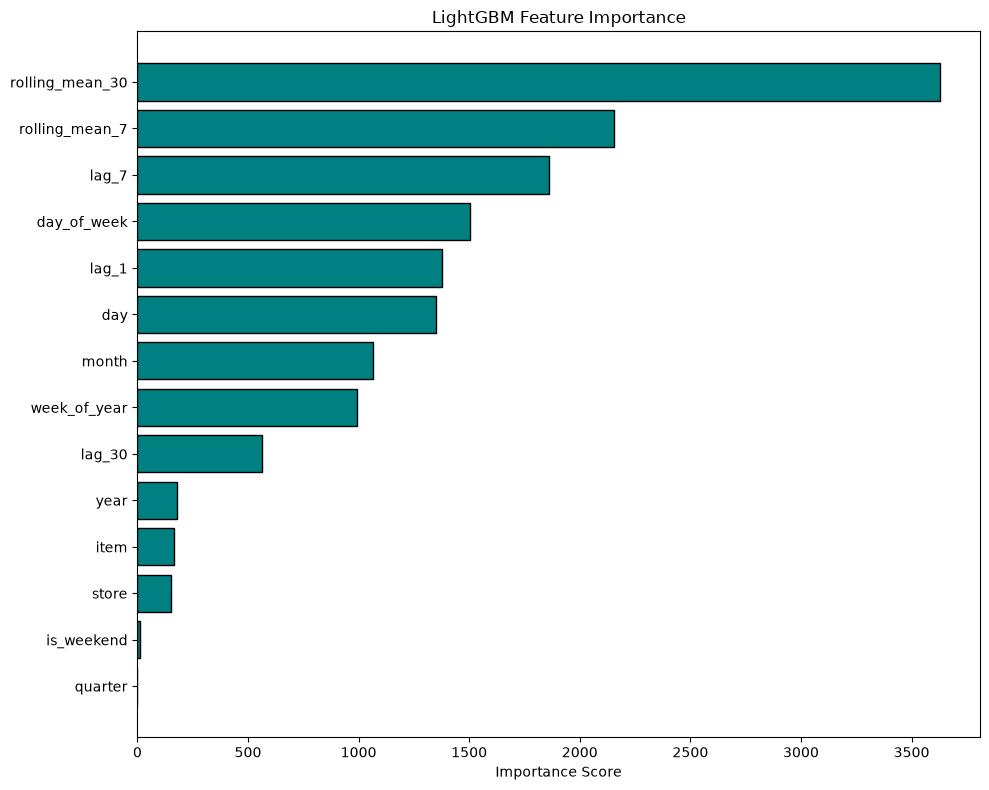

In [21]:
# 1. Create a DataFrame for feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
})

# 2. Sort features by importance in ascending order for a clean horizontal bar plot (highest at the top)
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

# 3. Plot feature importance using matplotlib
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal', edgecolor='black')

# 4. Add labels, title, and tight layout
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()

# Show the plot
plt.show()

### Key Observations

- Rolling mean features are the most influential predictors of future sales.
- Lag features also contribute significantly, highlighting the importance of historical demand.
- Calendar features such as day of the week and month help capture seasonal patterns.
- Store and item identifiers have relatively lower importance compared to historical sales features.
---

# SARIMA Model

**Objective:** Train a SARIMA model to forecast daily sales and compare its performance with the baseline and LightGBM models.

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Aggregate daily sales from the train dataset and set frequency to Daily
daily_sales = train.groupby("date")["sales"].sum().sort_index()
daily_sales = daily_sales.asfreq("D")

# 2. Split the series chronologically into train and validation sets
train_ts = daily_sales[daily_sales.index < '2017-10-01']
valid_ts = daily_sales[daily_sales.index >= '2017-10-01']

# 3. Train the SARIMA model with the specified orders
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results = sarima_model.fit(disp=False)

# 4. Forecast the sales for the validation period
sarima_pred = sarima_results.forecast(steps=len(valid_ts))

# 5. Calculate evaluation metrics
mae_sarima = mean_absolute_error(valid_ts, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(valid_ts, sarima_pred))
smape_sarima = calculate_smape(valid_ts, sarima_pred)

# 6. Display all evaluation metrics
print("SARIMA Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_sarima:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sarima:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {smape_sarima:.4f}%")

SARIMA Model Evaluation:
Mean Absolute Error (MAE): 3918.3520
Root Mean Squared Error (RMSE): 5577.5886
Symmetric Mean Absolute Percentage Error (SMAPE): 14.2203%


### Results

| Metric | Value |
|--------|------:|
| MAE | 3918.33 |
| RMSE | 5577.56 |
| SMAPE | 14.22% |

### Key Observations

- SARIMA captured the weekly seasonal pattern in the sales data.
- It performed better than the Naive Forecast model.
- LightGBM achieved the lowest forecasting error among the models evaluated so far.
- SARIMA serves as a strong statistical benchmark for comparison.

### Discussion

- A single SARIMA model was trained on the aggregated daily sales instead of building separate models for each store-item combination.
- This approach was chosen to keep the model computationally efficient while demonstrating the application of statistical forecasting.
- Training 500 individual SARIMA models would significantly increase computation time and complexity.
- SARIMA was used as a benchmark statistical model, while machine learning and deep learning models were evaluated for handling multiple store-item time series more effectively.
---

# LSTM Model

**Objective:** Train an LSTM model to learn sales patterns from historical data and evaluate its forecasting performance.

In [23]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize separate MinMaxScaler objects for features and targets
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# 2. Scale the input features
X_train_scaled = scaler_features.fit_transform(X_train)
X_valid_scaled = scaler_features.transform(X_valid)

# 3. Scale the target values (reshaping to 2D array is required for MinMaxScaler)
y_train_scaled = scaler_target.fit_transform(y_train.values.reshape(-1, 1))
y_valid_scaled = scaler_target.transform(y_valid.values.reshape(-1, 1))

# 4. Reshape the input features to match LSTM format: (samples, 1, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_valid_lstm = X_valid_scaled.reshape((X_valid_scaled.shape[0], 1, X_valid_scaled.shape[1]))

y_train_lstm = y_train_scaled
y_valid_lstm = y_valid_scaled

# 5. Display the shapes of the prepared datasets
print("LSTM Data Preparation Complete:")
print(f"X_train_lstm Shape : {X_train_lstm.shape}")
print(f"y_train_lstm Shape : {y_train_lstm.shape}")
print(f"X_valid_lstm Shape : {X_valid_lstm.shape}")
print(f"y_valid_lstm Shape : {y_valid_lstm.shape}")

LSTM Data Preparation Complete:
X_train_lstm Shape : (852000, 1, 14)
y_train_lstm Shape : (852000, 1)
X_valid_lstm Shape : (46000, 1, 14)
y_valid_lstm Shape : (46000, 1)


### Key Observations

- Feature and target values were scaled using MinMaxScaler.
- The input data was reshaped into the format required by the LSTM model.
- The prepared datasets are ready for model training and evaluation.
---

## Build and Train LSTM Model

**Objective:** Train an LSTM model and evaluate its forecasting performance on the validation dataset.

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Build the Sequential LSTM model
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)
])

# 2. Compile the model using Adam optimizer and Mean Squared Error loss
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Configure Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 4. Train the LSTM model
lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_lstm, y_valid_lstm),
    callbacks=[early_stopping],
    verbose=1
)

# 5. Predict on the scaled validation dataset
y_pred_scaled = lstm_model.predict(X_valid_lstm)

# 6. Convert predictions back to the original sales scale
y_pred_lstm = scaler_target.inverse_transform(y_pred_scaled).flatten()

# 7. Calculate evaluation metrics (comparing with original y_valid values)
mae_lstm = mean_absolute_error(y_valid, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_valid, y_pred_lstm))
smape_lstm = calculate_smape(y_valid, y_pred_lstm)

# 8. Print all evaluation metrics
print("\nLSTM Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {smape_lstm:.4f}%")


Epoch 1/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 2/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 3/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 4/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 60s 2ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 5/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 6/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 7/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 8/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 9/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 10/10
26625/26625 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - loss: 0.0011 - val_loss: 0.0013
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

LSTM Model Evaluation:
Mean Absolute Error (M

### Results

| Metric | Value |
|--------|------:|
| MAE | 6.3855 |
| RMSE | 8.3320 |
| SMAPE | 13.3418% |

### Key Observations

- LSTM successfully learned temporal patterns from the historical sales data.
- It outperformed both the Naive Forecast and the SARIMA model.
- LightGBM achieved the lowest forecasting error among all evaluated models.
- LSTM demonstrates the effectiveness of deep learning for retail demand forecasting.
---

# Model Persistence

**Objective:** Save trained models and preprocessing objects for future inference without retraining.

In [25]:
import os
import joblib

# 1. Create a folder named "models" if it does not already exist
models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created folder: {models_dir}")

# 2. Save the trained LightGBM model using joblib
joblib.dump(lgb_model, os.path.join(models_dir, 'lightgbm_model.pkl'))
print("Successfully saved LightGBM model to: models/lightgbm_model.pkl")

# 3. Save the trained SARIMA model (fitted results object) using joblib
joblib.dump(sarima_results, os.path.join(models_dir, 'sarima_model.pkl'))
print("Successfully saved SARIMA model to: models/sarima_model.pkl")

# 4. Save the trained LSTM model using the built-in save method
lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
print("Successfully saved LSTM model to: models/lstm_model.keras")

# 5. Save the feature scaler using joblib
joblib.dump(scaler_features, os.path.join(models_dir, 'feature_scaler.pkl'))
print("Successfully saved feature scaler to: models/feature_scaler.pkl")

# 6. Save the target scaler using joblib
joblib.dump(scaler_target, os.path.join(models_dir, 'target_scaler.pkl'))
print("Successfully saved target scaler to: models/target_scaler.pkl")

# 7. Display all files inside the "models" folder to verify success
print("\nVerification of saved models and objects:")
files_in_folder = os.listdir(models_dir)
for file_name in files_in_folder:
    print(f"- {file_name}")

Successfully saved LightGBM model to: models/lightgbm_model.pkl
Successfully saved SARIMA model to: models/sarima_model.pkl
Successfully saved LSTM model to: models/lstm_model.keras
Successfully saved feature scaler to: models/feature_scaler.pkl
Successfully saved target scaler to: models/target_scaler.pkl

Verification of saved models and objects:
- feature_scaler.pkl
- lightgbm_model.pkl
- lstm_model.keras
- sarima_model.pkl
- target_scaler.pkl


## Key Observations

- LightGBM, SARIMA, and LSTM models were successfully saved.
- Feature and target scalers were preserved.
- Saved models can be directly loaded for future forecasting or deployment.
---

# Model Comparison

**Objective:** Compare the forecasting performance of all developed models using evaluation metrics and identify the most suitable model for retail demand forecasting.

Model Evaluation Comparison Table:
         Model         MAE        RMSE     SMAPE
Naive Forecast   10.755239   14.616037 21.535628
        SARIMA 3918.351996 5577.588646 14.220278
      LightGBM    5.915156    7.650910 12.470442
          LSTM    6.385460    8.321988 13.341754


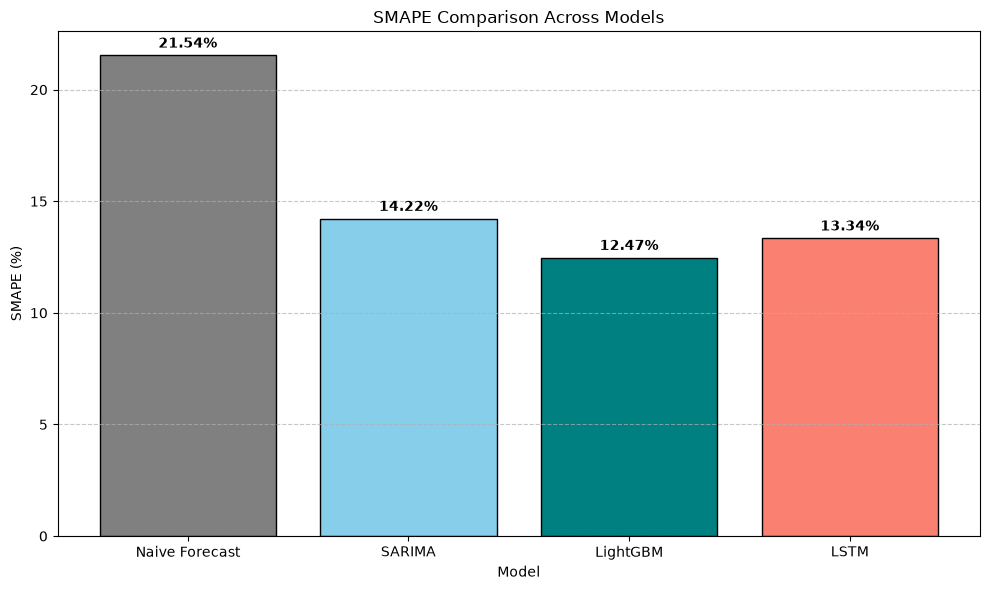


Best Performing Model: LightGBM (SMAPE: 12.47%)


In [26]:
# 1. Create a pandas DataFrame containing evaluation metrics for all models
model_comparison = pd.DataFrame({
    'Model': ['Naive Forecast', 'SARIMA', 'LightGBM', 'LSTM'],
    'MAE': [mae_naive, mae_sarima, mae_lgb, mae_lstm],
    'RMSE': [rmse_naive, rmse_sarima, rmse_lgb, rmse_lstm],
    'SMAPE': [smape_naive, smape_sarima, smape_lgb, smape_lstm]
})

# 2. Display the comparison table
print("Model Evaluation Comparison Table:")
print(model_comparison.to_string(index=False))

# 3. Create a bar chart comparing the SMAPE values of all models using matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(model_comparison['Model'], model_comparison['SMAPE'], color=['grey', 'skyblue', 'teal', 'salmon'], edgecolor='black')

# 4. Add value labels above each bar for readability
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

# 5. Add chart elements (title, labels, grid, and tight layout)
plt.title('SMAPE Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('SMAPE (%)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

# 6. Print the best-performing model based on the lowest SMAPE score
best_model_idx = model_comparison['SMAPE'].idxmin()
best_model = model_comparison.loc[best_model_idx]
print(f"\nBest Performing Model: {best_model['Model']} (SMAPE: {best_model['SMAPE']:.2f}%)")

> **Note:** The SARIMA model was trained on aggregated daily sales, while the Naive Forecast, LightGBM, and LSTM models were trained on individual store-item sales records. Therefore, MAE and RMSE values are not directly comparable across SARIMA and the other models. SMAPE is used as the primary metric for model comparison because it is scale-independent.

## Key Observations

- LightGBM achieved the lowest SMAPE and was selected as the final forecasting model.
- LSTM also produced strong forecasting performance but required higher computational resources and training time.
- SARIMA successfully captured seasonal patterns in the aggregated sales series but was less effective than the machine learning models.
- The Naive Forecast served as a baseline model and produced the highest forecasting error.
- Overall, feature-engineered machine learning models outperformed the statistical forecasting approach for this dataset.
---

# Final Model Training and Test Prediction

**Objective:** Retrain the best-performing model using the complete training dataset and generate sales predictions for the unseen test dataset.

In [27]:
# 1. Define features and target variable for the final model
final_features = [
    'store', 'item', 'year', 'month', 'day', 'day_of_week', 
    'week_of_year', 'quarter', 'is_weekend', 
    'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30'
]
final_target = 'sales'

# 2. Prepare the complete processed training dataset
X_final = train[final_features]
y_final = train[final_target]

print("Training samples:", X_final.shape[0])
print("Number of features:", X_final.shape[1])

# 3. Initialize a new LightGBM Regressor with the same hyperparameters
final_lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

# 4. Retrain the model on the complete processed dataset
final_lgb_model.fit(X_final, y_final)

# 5. Print a confirmation message after successful training
print("Final LightGBM model has been successfully retrained on the complete processed dataset.")


Training samples: 898000
Number of features: 14
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1259
[LightGBM] [Info] Number of data points in the train set: 898000, number of used features: 14
[LightGBM] [Info] Start training from score 52.632886
Final LightGBM model has been successfully retrained on the complete processed dataset.


In [28]:
from collections import deque
import numpy as np

# Store the last 30 actual sales for every (store, item)
history = {}

for (store, item), group in train.groupby(["store", "item"]):
    history[(store, item)] = deque(
        group.sort_values("date")["sales"].tail(30).tolist(),
        maxlen=30
    )

print("Total Store-Item Histories:", len(history))
print("Example History:")
print(history[(1, 1)])

Total Store-Item Histories: 500
Example History:
deque([16, 31, 7, 20, 17, 18, 17, 27, 20, 20, 13, 17, 14, 16, 15, 22, 19, 7, 16, 12, 6, 18, 19, 13, 16, 14, 19, 15, 27, 23], maxlen=30)


# Recursive Multi-step Forecasting

**Objective:** Generate future sales predictions recursively by updating lag and rolling features after each prediction, ensuring realistic forecasting without using future information.

In [34]:
# Create a list to store predictions
predictions = []

# Iterate through each date in the test set chronologically
for current_date in sorted(test["date"].unique()):

    # Get all rows for the current date
    current_rows = test[test["date"] == current_date].copy()

    feature_rows = []

    for _, row in current_rows.iterrows():

        key = (row["store"], row["item"])
        hist = history[key]

        feature_rows.append({
            "store": row["store"],
            "item": row["item"],
            "year": row["year"],
            "month": row["month"],
            "day": row["day"],
            "day_of_week": row["day_of_week"],
            "week_of_year": row["week_of_year"],
            "quarter": row["quarter"],
            "is_weekend": row["is_weekend"],

            "lag_1": hist[-1],
            "lag_7": hist[-7],
            "lag_30": hist[-30],

            "rolling_mean_7": np.mean(list(hist)[-7:]),
            "rolling_mean_30": np.mean(hist)
        })

    # Convert to DataFrame
    X_day = pd.DataFrame(feature_rows)[final_features]

    # Predict today's sales
    day_predictions = final_lgb_model.predict(X_day)

    
    for i, (_, row) in enumerate(current_rows.iterrows()):

        prediction = float(day_predictions[i])

        predictions.append({
            "id": row["id"],
            "sales": prediction
        })

        key = (row["store"], row["item"])
        history[key].append(round(prediction, 2))


## Key Observations

- Recursive forecasting predicts one day at a time.
- Predicted sales are appended to historical observations before forecasting the next day.
- Lag and rolling features are updated dynamically after every prediction.
- This approach prevents data leakage while enabling multi-step forecasting.
---

# Submission File Generation

**Objective:** Generate the final prediction file in the required competition format.

In [35]:

# Create submission AFTER the loop
submission = pd.DataFrame(predictions)
submission = submission.sort_values("id").reset_index(drop=True)

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Submission Shape:", submission.shape)
print("Total Predictions:", len(submission))

   id      sales
0   0  15.960647
1   1  18.659607
2   2  18.643945
3   3  19.675698
4   4  21.810229
Submission Shape: (45000, 2)
Total Predictions: 45000


## Key Observations

- Successfully generated predictions for all test observations.
- Submission file contains the required `id` and `sales` columns.
- No missing values were found.
- The generated file is ready for deployment or competition submission.
---

## Kaggle Score: 
- Got `13.077`  through final lightGBM Model.
---

# Project Summary

## Overview

This project developed an end-to-end retail demand forecasting pipeline using historical sales data from multiple stores and products.

## Major Steps Performed

- Data loading and preprocessing
- Exploratory Data Analysis
- Time-series decomposition
- Stationarity analysis using the Augmented Dickey-Fuller test
- Feature engineering using calendar, lag, and rolling statistics
- Baseline forecasting using Naive Forecast
- Statistical forecasting using SARIMA
- Machine learning forecasting using LightGBM
- Deep learning forecasting using LSTM
- Model comparison using MAE, RMSE, and SMAPE
- Recursive multi-step forecasting
- Final prediction generation
- Model persistence

# Future Scope

The forecasting system can be further improved by:

- Adding additional lag features such as lag_90, lag_180, and lag_365.
- Incorporating exponential moving averages (EMA) and rolling standard deviation features.
- Performing LightGBM hyperparameter optimization using Optuna or RandomizedSearchCV.
- Including holiday and promotional information as external variables.
- Applying TimeSeriesSplit cross-validation for more robust evaluation.
- Deploying the trained model using FastAPI or Flask for real-time demand forecasting.
- Automating model retraining using workflow orchestration tools such as Airflow.

# Conclusion

This project successfully developed a complete demand forecasting pipeline for retail sales prediction using statistical, machine learning, and deep learning approaches.

Among all evaluated models, LightGBM achieved the best forecasting performance with the lowest validation SMAPE and was selected as the final forecasting model.

Recursive multi-step forecasting enabled realistic prediction of future sales by dynamically updating lag and rolling features after each prediction, eliminating data leakage while preserving temporal dependencies.

The final solution demonstrates a complete machine learning workflow, including data preprocessing, feature engineering, model development, evaluation, recursive forecasting, model persistence, and prediction generation, making it suitable for real-world retail demand forecasting applications.